In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error


In [2]:
df = pd.read_csv("/content/student_performance.csv")
df

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A
...,...,...,...,...,...,...
824189,824190,12.3,94.0,4.4,83.0,B
824190,824191,9.5,99.5,7.7,66.8,C
824191,824192,22.1,100.0,7.9,98.3,A
824192,824193,9.5,93.2,4.0,64.6,C


In [3]:
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [4]:
df.shape

(824194, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824194 entries, 0 to 824193
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               824194 non-null  int64  
 1   weekly_self_study_hours  824194 non-null  float64
 2   attendance_percentage    824193 non-null  float64
 3   class_participation      824193 non-null  float64
 4   total_score              824193 non-null  float64
 5   grade                    824193 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 37.7+ MB


In [6]:
df.describe()


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,824194.000000,824194.000000,824193.000000,824193.000000,824193.000000
mean,412097.500000,15.036966,84.707843,5.984330,84.291756
std,237924.458221,6.900048,9.424770,1.956855,15.428712
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,206049.250000,10.300000,78.300000,4.700000,73.900000
50%,412097.500000,15.000000,85.000000,6.000000,87.500000
75%,618145.750000,19.700000,91.700000,7.300000,100.000000
max,824194.000000,40.000000,100.000000,10.000000,100.000000


In [7]:
df.isnull().sum()

,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,1
class_participation,1
total_score,1
grade,1


In [8]:
#as the data is large..
df_sample = df.sample(n=5000, random_state=17)
df_sample

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
242272,242273,0.0,100.0,8.5,53.6,D
694603,694604,36.2,89.2,5.9,100.0,A
391981,391982,19.1,71.1,5.7,100.0,A
761134,761135,24.2,78.3,6.1,95.0,A
493662,493663,15.2,84.8,4.9,80.2,B
...,...,...,...,...,...,...
212114,212115,2.6,83.7,6.0,47.5,D
138723,138724,22.6,88.8,7.9,100.0,A
673404,673405,14.6,86.6,5.0,75.1,B
2883,2884,18.2,81.8,4.5,96.0,A


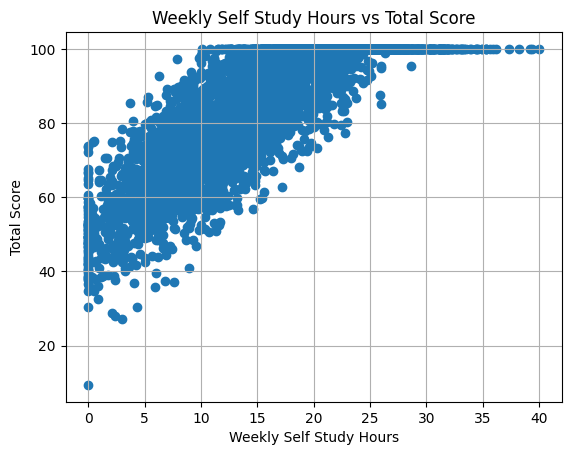

In [11]:
plt.scatter(df_sample['weekly_self_study_hours'], df_sample['total_score'])
plt.title('Weekly Self Study Hours vs Total Score')
plt.xlabel('Weekly Self Study Hours')
plt.ylabel('Total Score')
plt.grid(True)
plt.show()

In [18]:
features = ['weekly_self_study_hours', "attendance_percentage", 'class_participation']
target = 'total_score'

x = df_sample[features]
y = df_sample[target]

In [14]:
x.head()

,weekly_self_study_hours,attendance_percentage,class_participation
242272,0.0,100.0,8.5
694603,36.2,89.2,5.9
391981,19.1,71.1,5.7
761134,24.2,78.3,6.1
493662,15.2,84.8,4.9


In [16]:
y.head()

,total_score
242272,53.6
694603,100.0
391981,100.0
761134,95.0
493662,80.2


In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [20]:
model = LinearRegression()
model.fit(x_train, y_train)
coefficients = model.coef_
intercept = model.intercept_
print("Coefficients:", coefficients)
print("Intercept:", intercept)

Coefficients: [ 1.82456812  0.01659391 -0.11648656]
Intercept: 56.013032791071865


In [21]:
y_predict = model.predict(x_test)
compare = pd.DataFrame({'Actual': y_test[:10].values, 'Predicted': y_predict[:10]})
compare

,Actual,Predicted
0,68.5,76.374480
1,100.0,94.654370
2,81.5,74.545483
3,100.0,113.621001
4,100.0,100.082027
5,52.3,56.907293
6,88.5,81.899757
7,97.3,77.368875
8,82.1,78.574544
9,56.6,59.961737


In [22]:
r2 = r2_score(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

R-squared: 0.6659435108793184
Mean Absolute Error: 7.354746441063588
Mean Squared Error: 83.03013808523912
